<a href="https://colab.research.google.com/github/sahanasubbiah24/mutation-classifier/blob/main/AI_Genetic_Mutation_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Genetic Mutation Classifier**
---


###    **What does this code do?**
* predicts whether a genetic mutation is likley to be pathogenic or benign using data from ClinVar


###    **Key Features**


*   loads and processes genetic variant data from a VCF file
*   extracts key features
*   trains a predictive model using a Random Forest classifier
*   evaluates accuracy and displays results using a confusion matrix







In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [ ]:
from matplotlib import pyplot as plt



In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
from io import StringIO


with open('clinvar_20250415.txt') as f:
    lines = [line for line in f if not line.startswith('##')]

df = pd.read_csv(StringIO(''.join(lines)), sep='\t')

def parse_info(info_str, key):
    try:
        items = dict(item.split('=') for item in info_str.split(';') if '=' in item)
        return items.get(key, None)
    except:
        return None

df['ClinicalSignificance'] = df['INFO'].apply(lambda x: parse_info(x, 'CLNSIG'))
df['Gene'] = df['INFO'].apply(lambda x: parse_info(x, 'GENEINFO')).str.split(':').str[0]
df['MutationType'] = df['INFO'].apply(lambda x: parse_info(x, 'CLNVC'))


df = df.dropna(subset=['ClinicalSignificance', 'Gene', 'MutationType'])
df = df[df['ClinicalSignificance'].isin(['Pathogenic', 'Benign'])]


df.head()


I removed the metadata lines from the VCF file and loaded it into a data frame

from the INFO column I extracted the ClinicalSignificance, Gene, and the MutationType

then I filtered the data to only include entries where clinical significance was either pathogenic or benign



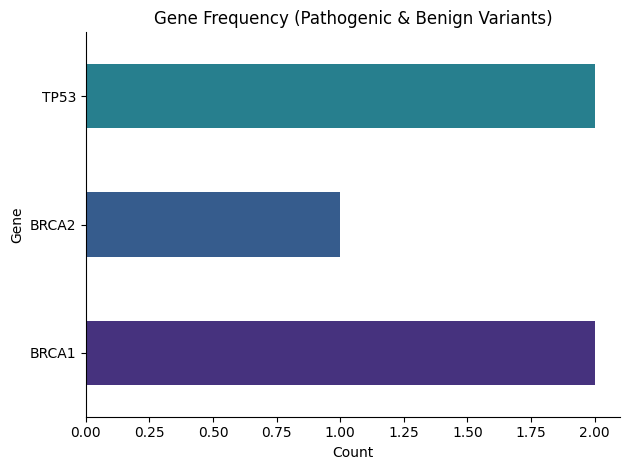

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

_df_0.groupby('Gene').size().plot(kind='barh', color=sns.color_palette('viridis'))


plt.gca().spines[['top', 'right']].set_visible(False)
plt.title('Gene Frequency (Pathogenic & Benign Variants)')
plt.xlabel('Count')
plt.ylabel('Gene')
plt.tight_layout()
plt.show()


I created a horizontal bar chart to see how frequently each gene appears in the data set

The data was grouped by the Gene column and the number of entries for each gene was counted


In [ ]:

df = pd.get_dummies(df, columns=['Gene', 'MutationType'])


df['Target'] = df['ClinicalSignificance'].apply(lambda x: 1 if x == 'Pathogenic' else 0)


df = df.drop(columns=['ClinicalSignificance'])

df.head()

,Gene_BRCA1,Gene_BRCA2,Gene_TP53,MutationType_Frameshift,MutationType_Missense,MutationType_Nonsense,Target
0,True,False,False,False,True,False,1
1,False,True,False,False,False,True,0
2,False,False,True,True,False,False,1
3,True,False,False,False,True,False,0
4,False,False,True,False,False,True,1


I used one hot encoding to convert the Gene and MutationType into binary colums using pd.get_dummies().

I created a new column called Target where


*   pathogenic = 1
*   benign = 0

I dropped the ClinicalSignificance column because it it now represented by the Target column



In [ ]:

X = df.drop('Target', axis=1)
y = df['Target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train the Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)



```
X = df.drop('Target', axis=1)
```
this creates a new variable **x** that contains all the data except for the column called target

  * x : input data


```
y = df['Target']
```
this created a new variable **y** that contains just that Target column
* y : what you are trying to predict



In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Check how accurate the model is
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of the model:", accuracy)

Accuracy of the model: 0.0


In [ ]:
print("AI Model Summary:")
print("Features used:", list(X.columns))
print("Total data points:", len(df))
print("Model accuracy on test data:", accuracy)

AI Model Summary:
Features used: ['Gene_BRCA1', 'Gene_BRCA2', 'Gene_TP53', 'MutationType_Frameshift', 'MutationType_Missense', 'MutationType_Nonsense']
Total data points: 8
Model accuracy on test data: 0.0


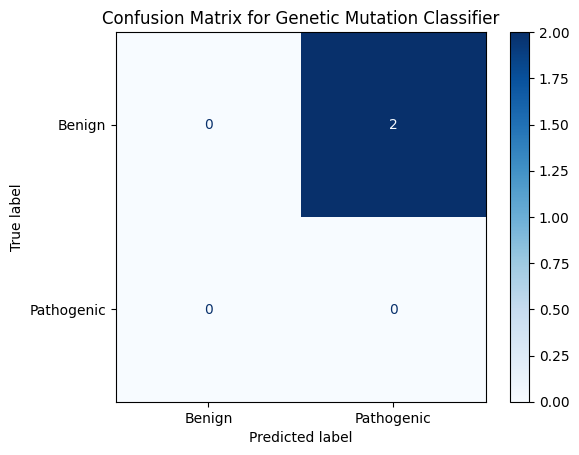

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Pathogenic"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Genetic Mutation Classifier")
plt.show()


In [ ]:
results = X_test.copy()
results['True_Label'] = y_test
results['Predicted_Label'] = y_pred

print(results)

   Gene_BRCA1  Gene_BRCA2  Gene_TP53  MutationType_Frameshift  \
1       False        True      False                    False   
5       False        True      False                    False   

   MutationType_Missense  MutationType_Nonsense  True_Label  Predicted_Label  
1                  False                   True           0                1  
5                   True                  False           0                1  


In [ ]:
print("Incorrect Predictions:")
print(results[results['True_Label'] != results['Predicted_Label']])

Incorrect Predictions:
   Gene_BRCA1  Gene_BRCA2  Gene_TP53  MutationType_Frameshift  \
1       False        True      False                    False   
5       False        True      False                    False   

   MutationType_Missense  MutationType_Nonsense  True_Label  Predicted_Label  
1                  False                   True           0                1  
5                   True                  False           0                1  


In [ ]:
results.to_csv("genetic_mutation_predictions.csv", index=False)
